# SwiftTech Sales Performance Audit
## Author: Sahil Kumar
### Objective: 
To analyze raw sales data, clean inconsistencies, and identify key revenue drivers and regional performance for SwiftTech Electronics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generating the dataset
data = {
    'Order_ID': [1, 2, 3, 4, 5],
    'Product': ['Laptop', 'Mouse', 'Monitor', 'Laptop', 'Mouse'],
    'Sales_Amount': [1200, 25, 300, 1200, -50],
    'Region': ['North', 'north', 'South', 'East', 'North']
}

df = pd.DataFrame(data)
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1. Initial Data Inspection
Before cleaning, we check the 'health' of our data to identify missing values, data types, and statistical anomalies.

In [6]:
print("--- Data Info ---")
df.info()

print("\n--- Descriptive Statistics ---")
print(df.describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order_ID      5 non-null      int64 
 1   Product       5 non-null      object
 2   Sales_Amount  5 non-null      int64 
 3   Region        5 non-null      object
dtypes: int64(2), object(2)
memory usage: 292.0+ bytes

--- Descriptive Statistics ---
       Order_ID  Sales_Amount
count  5.000000      5.000000
mean   3.000000    535.000000
std    1.581139    620.886463
min    1.000000    -50.000000
25%    2.000000     25.000000
50%    3.000000    300.000000
75%    4.000000   1200.000000
max    5.000000   1200.000000


## 2. Data Cleaning & Transformation
**Observations:**
* The `Region` column has inconsistent casing ('north' vs 'North').
* The `Sales_Amount` contains a negative value (-50), likely a refund.
* We will standardize the text and filter out refunds to focus on gross revenue.

In [9]:
# Standardize Region casing
df['Region'] = df['Region'].str.title()

# Filter for positive sales only
df_cleaned = df[df['Sales_Amount'] > 0].copy()

# Ensure data types are correct for analysis
df_cleaned['Sales_Amount'] = df_cleaned['Sales_Amount'].astype(float)

print("Cleaning complete. Data filtered from {} to {} rows.".format(len(df), len(df_cleaned)))

Cleaning complete. Data filtered from 5 to 4 rows.


## 3. Business Analysis
We are calculating:
1. **Product Revenue:** To find the top-selling item.
2. **Regional Volume:** To identify our most active market.

In [12]:
# Grouping by Product
product_rev = df_cleaned.groupby('Product')['Sales_Amount'].sum().sort_values(ascending=False)

# Grouping by Region
region_counts = df_cleaned.groupby('Region')['Order_ID'].count()

print(product_rev)
print(region_counts)

Product
Laptop     2400.0
Monitor     300.0
Mouse        25.0
Name: Sales_Amount, dtype: float64
Region
East     1
North    2
South    1
Name: Order_ID, dtype: int64


## 4. Visualizing Results
Visual representation of the revenue distribution across the company.

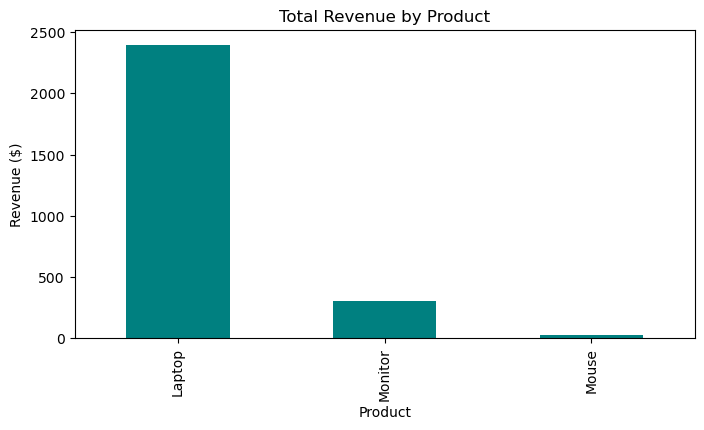

In [15]:
# Plotting Product Revenue
plt.figure(figsize=(8,4))
product_rev.plot(kind='bar', color='teal')
plt.title('Total Revenue by Product')
plt.ylabel('Revenue ($)')
plt.show()

## Final Insights
* **Top Product:** Laptops are the primary revenue driver.
* **Top Region:** The North region leads in order volume.
* **Action Item:** Investigate low volume in East/South regions for growth opportunities.

Subject: Sales Audit Findings - SwiftTech Electronics

I have completed the audit of our recent sales data. Here are the key takeaways:

Data Quality: We identified inconsistencies in regional naming (North vs north) and found a negative entry of -$50 which was flagged as a potential refund.

Revenue Driver: Laptops are our highest-grossing product, contributing $2,400 in the audited period.

Regional Performance: The North region is our most active hub, accounting for 50% of our total order volume.

Recommendation: We should investigate why the "South" and "East" regions have 50% less volume than the North to see if we need a targeted marketing push there.